<a href="https://colab.research.google.com/github/cleanesantos/aulas-modelos-datascience/blob/main/Regressao_Linear_Aula_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão linear: publicidade, vendas e preços de imóveis
## iCEV | Aula prática em Python

**Parte 1:** regressão linear simples para analisar a relação entre investimento em publicidade na TV e vendas.

**Parte 2:** regressão linear simples e múltipla para analisar a relação entre área, localização e valor dos imóveis.

Abra o arquivo no Google Colab pela opção de upload de notebook. As duas bases de dados estão incorporadas ao arquivo. Não é necessário baixar ou enviar CSVs.

Execute as células na ordem ou selecione **Ambiente de execução > Executar tudo**.

### Bases de dados

- **Publicidade e vendas:** [Advertising.csv](https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv).


- **Imóveis:** [dataset.csv](https://github.com/RafaelxFernandes/Data-Science-e-Deep-Learning/blob/master/8%20-%20Regress%C3%A3o%20Linear_%20T%C3%A9cnicas%20Avan%C3%A7adas%20de%20Modelagem/Dados/dataset.csv).

## 1. O que queremos estimar?
Uma regressão descreve uma associação entre uma variável resposta e uma ou mais variáveis explicativas.

$$Y_i=\beta_0+\beta_1X_i+\varepsilon_i$$

$$\widehat{Y}_i=\widehat{\beta}_0+\widehat{\beta}_1X_i$$

**X:** variável explicativa.

**Y:** variável resposta.

**Intercepto:** previsão quando X = 0.

**Coeficiente angular:** variação na previsão associada ao aumento de uma unidade em X.

**Resíduo:** observado menos previsto.

A regressão, por si só, não demonstra causalidade.

## 2. Bibliotecas
Pandas organiza as tabelas; Matplotlib e Seaborn produzem gráficos; scikit-learn ajusta e avalia os modelos; statsmodels apresenta resultados estatísticos.

In [ ]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)

# Parte 1. Publicidade na TV e vendas
**Pergunta:** maiores investimentos em TV estão associados a maiores vendas?

Usaremos a base clássica Advertising, com 200 observações. Os nomes foram traduzidos. A cópia incorporada foi obtida no repositório selva86/datasets, identificado ao final. Não atribua estes valores a uma empresa brasileira nem os apresente em reais. Mantemos as escalas numéricas da base e usamos “unidades da base” nas interpretações.

In [ ]:
csv_publicidade = ',TV,radio,newspaper,sales\n1,230.1,37.8,69.2,22.1\n2,44.5,39.3,45.1,10.4\n3,17.2,45.9,69.3,9.3\n4,151.5,41.3,58.5,18.5\n5,180.8,10.8,58.4,12.9\n6,8.7,48.9,75,7.2\n7,57.5,32.8,23.5,11.8\n8,120.2,19.6,11.6,13.2\n9,8.6,2.1,1,4.8\n10,199.8,2.6,21.2,10.6\n11,66.1,5.8,24.2,8.6\n12,214.7,24,4,17.4\n13,23.8,35.1,65.9,9.2\n14,97.5,7.6,7.2,9.7\n15,204.1,32.9,46,19\n16,195.4,47.7,52.9,22.4\n17,67.8,36.6,114,12.5\n18,281.4,39.6,55.8,24.4\n19,69.2,20.5,18.3,11.3\n20,147.3,23.9,19.1,14.6\n21,218.4,27.7,53.4,18\n22,237.4,5.1,23.5,12.5\n23,13.2,15.9,49.6,5.6\n24,228.3,16.9,26.2,15.5\n25,62.3,12.6,18.3,9.7\n26,262.9,3.5,19.5,12\n27,142.9,29.3,12.6,15\n28,240.1,16.7,22.9,15.9\n29,248.8,27.1,22.9,18.9\n30,70.6,16,40.8,10.5\n31,292.9,28.3,43.2,21.4\n32,112.9,17.4,38.6,11.9\n33,97.2,1.5,30,9.6\n34,265.6,20,0.3,17.4\n35,95.7,1.4,7.4,9.5\n36,290.7,4.1,8.5,12.8\n37,266.9,43.8,5,25.4\n38,74.7,49.4,45.7,14.7\n39,43.1,26.7,35.1,10.1\n40,228,37.7,32,21.5\n41,202.5,22.3,31.6,16.6\n42,177,33.4,38.7,17.1\n43,293.6,27.7,1.8,20.7\n44,206.9,8.4,26.4,12.9\n45,25.1,25.7,43.3,8.5\n46,175.1,22.5,31.5,14.9\n47,89.7,9.9,35.7,10.6\n48,239.9,41.5,18.5,23.2\n49,227.2,15.8,49.9,14.8\n50,66.9,11.7,36.8,9.7\n51,199.8,3.1,34.6,11.4\n52,100.4,9.6,3.6,10.7\n53,216.4,41.7,39.6,22.6\n54,182.6,46.2,58.7,21.2\n55,262.7,28.8,15.9,20.2\n56,198.9,49.4,60,23.7\n57,7.3,28.1,41.4,5.5\n58,136.2,19.2,16.6,13.2\n59,210.8,49.6,37.7,23.8\n60,210.7,29.5,9.3,18.4\n61,53.5,2,21.4,8.1\n62,261.3,42.7,54.7,24.2\n63,239.3,15.5,27.3,15.7\n64,102.7,29.6,8.4,14\n65,131.1,42.8,28.9,18\n66,69,9.3,0.9,9.3\n67,31.5,24.6,2.2,9.5\n68,139.3,14.5,10.2,13.4\n69,237.4,27.5,11,18.9\n70,216.8,43.9,27.2,22.3\n71,199.1,30.6,38.7,18.3\n72,109.8,14.3,31.7,12.4\n73,26.8,33,19.3,8.8\n74,129.4,5.7,31.3,11\n75,213.4,24.6,13.1,17\n76,16.9,43.7,89.4,8.7\n77,27.5,1.6,20.7,6.9\n78,120.5,28.5,14.2,14.2\n79,5.4,29.9,9.4,5.3\n80,116,7.7,23.1,11\n81,76.4,26.7,22.3,11.8\n82,239.8,4.1,36.9,12.3\n83,75.3,20.3,32.5,11.3\n84,68.4,44.5,35.6,13.6\n85,213.5,43,33.8,21.7\n86,193.2,18.4,65.7,15.2\n87,76.3,27.5,16,12\n88,110.7,40.6,63.2,16\n89,88.3,25.5,73.4,12.9\n90,109.8,47.8,51.4,16.7\n91,134.3,4.9,9.3,11.2\n92,28.6,1.5,33,7.3\n93,217.7,33.5,59,19.4\n94,250.9,36.5,72.3,22.2\n95,107.4,14,10.9,11.5\n96,163.3,31.6,52.9,16.9\n97,197.6,3.5,5.9,11.7\n98,184.9,21,22,15.5\n99,289.7,42.3,51.2,25.4\n100,135.2,41.7,45.9,17.2\n101,222.4,4.3,49.8,11.7\n102,296.4,36.3,100.9,23.8\n103,280.2,10.1,21.4,14.8\n104,187.9,17.2,17.9,14.7\n105,238.2,34.3,5.3,20.7\n106,137.9,46.4,59,19.2\n107,25,11,29.7,7.2\n108,90.4,0.3,23.2,8.7\n109,13.1,0.4,25.6,5.3\n110,255.4,26.9,5.5,19.8\n111,225.8,8.2,56.5,13.4\n112,241.7,38,23.2,21.8\n113,175.7,15.4,2.4,14.1\n114,209.6,20.6,10.7,15.9\n115,78.2,46.8,34.5,14.6\n116,75.1,35,52.7,12.6\n117,139.2,14.3,25.6,12.2\n118,76.4,0.8,14.8,9.4\n119,125.7,36.9,79.2,15.9\n120,19.4,16,22.3,6.6\n121,141.3,26.8,46.2,15.5\n122,18.8,21.7,50.4,7\n123,224,2.4,15.6,11.6\n124,123.1,34.6,12.4,15.2\n125,229.5,32.3,74.2,19.7\n126,87.2,11.8,25.9,10.6\n127,7.8,38.9,50.6,6.6\n128,80.2,0,9.2,8.8\n129,220.3,49,3.2,24.7\n130,59.6,12,43.1,9.7\n131,0.7,39.6,8.7,1.6\n132,265.2,2.9,43,12.7\n133,8.4,27.2,2.1,5.7\n134,219.8,33.5,45.1,19.6\n135,36.9,38.6,65.6,10.8\n136,48.3,47,8.5,11.6\n137,25.6,39,9.3,9.5\n138,273.7,28.9,59.7,20.8\n139,43,25.9,20.5,9.6\n140,184.9,43.9,1.7,20.7\n141,73.4,17,12.9,10.9\n142,193.7,35.4,75.6,19.2\n143,220.5,33.2,37.9,20.1\n144,104.6,5.7,34.4,10.4\n145,96.2,14.8,38.9,11.4\n146,140.3,1.9,9,10.3\n147,240.1,7.3,8.7,13.2\n148,243.2,49,44.3,25.4\n149,38,40.3,11.9,10.9\n150,44.7,25.8,20.6,10.1\n151,280.7,13.9,37,16.1\n152,121,8.4,48.7,11.6\n153,197.6,23.3,14.2,16.6\n154,171.3,39.7,37.7,19\n155,187.8,21.1,9.5,15.6\n156,4.1,11.6,5.7,3.2\n157,93.9,43.5,50.5,15.3\n158,149.8,1.3,24.3,10.1\n159,11.7,36.9,45.2,7.3\n160,131.7,18.4,34.6,12.9\n161,172.5,18.1,30.7,14.4\n162,85.7,35.8,49.3,13.3\n163,188.4,18.1,25.6,14.9\n164,163.5,36.8,7.4,18\n165,117.2,14.7,5.4,11.9\n166,234.5,3.4,84.8,11.9\n167,17.9,37.6,21.6,8\n168,206.8,5.2,19.4,12.2\n169,215.4,23.6,57.6,17.1\n170,284.3,10.6,6.4,15\n171,50,11.6,18.4,8.4\n172,164.5,20.9,47.4,14.5\n173,19.6,20.1,17,7.6\n174,168.4,7.1,12.8,11.7\n175,222.4,3.4,13.1,11.5\n176,276.9,48.9,41.8,27\n177,248.4,30.2,20.3,20.2\n178,170.2,7.8,35.2,11.7\n179,276.7,2.3,23.7,11.8\n180,165.6,10,17.6,12.6\n181,156.6,2.6,8.3,10.5\n182,218.5,5.4,27.4,12.2\n183,56.2,5.7,29.7,8.7\n184,287.6,43,71.8,26.2\n185,253.8,21.3,30,17.6\n186,205,45.1,19.6,22.6\n187,139.5,2.1,26.6,10.3\n188,191.1,28.7,18.2,17.3\n189,286,13.9,3.7,15.9\n190,18.7,12.1,23.4,6.7\n191,39.5,41.1,5.8,10.8\n192,75.5,10.8,6,9.9\n193,17.2,4.1,31.6,5.9\n194,166.8,42,3.6,19.6\n195,149.7,35.6,6,17.3\n196,38.2,3.7,13.8,7.6\n197,94.2,4.9,8.1,9.7\n198,177,9.3,6.4,12.8\n199,283.6,42,66.2,25.5\n200,232.1,8.6,8.7,13.4\n'
publicidade = pd.read_csv(io.StringIO(csv_publicidade), index_col=0)
publicidade = publicidade.rename(columns={"TV": "TV", "radio": "Radio", "newspaper": "Jornal", "sales": "Vendas"})
publicidade.head()

,TV,Radio,Jornal,Vendas
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## 3. Conhecendo a tabela
Cada linha corresponde a uma observação. TV, Radio e Jornal são investimentos em canais de publicidade; Vendas é a resposta. Nesta primeira parte, apenas TV entra no modelo.

In [ ]:
print("Linhas e colunas:", publicidade.shape)
publicidade.info()
display(publicidade.isna().sum().to_frame("Ausentes"))
display(publicidade.describe().round(2))

Linhas e colunas: (200, 4)
<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Radio   200 non-null    float64
 2   Jornal  200 non-null    float64
 3   Vendas  200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


,Ausentes
TV,0
Radio,0
Jornal,0
Vendas,0


,TV,Radio,Jornal,Vendas
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


## 4. Dispersão e correlação
A dispersão permite observar direção, forma e pontos afastados. A correlação de Pearson resume a associação linear, entre −1 e 1. Correlação alta não prova que aumentar o orçamento causa aumento das vendas.

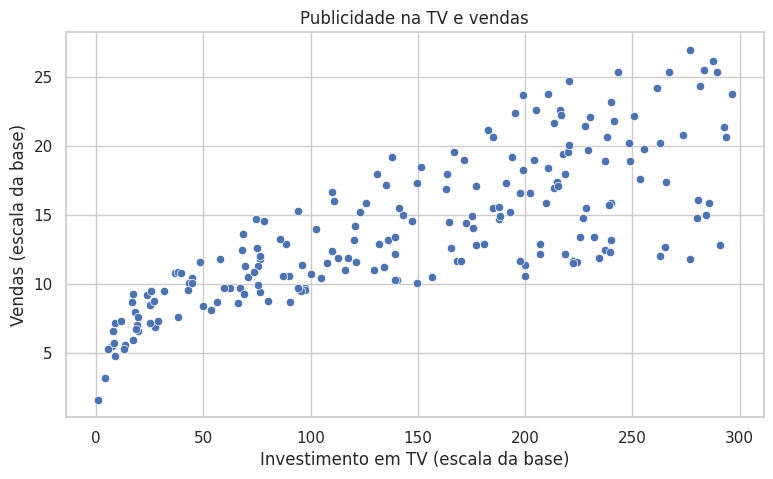

Correlação: 0.7822


In [ ]:
sns.scatterplot(data=publicidade, x="TV", y="Vendas")
plt.title("Publicidade na TV e vendas")
plt.xlabel("Investimento em TV (escala da base)")
plt.ylabel("Vendas (escala da base)")
plt.show()
print("Correlação:", round(publicidade["TV"].corr(publicidade["Vendas"]), 4))

## 5. Separando treino e teste
Ajustamos os parâmetros no treino (70%) e avaliamos previsões no teste (30%). O teste permanece separado do ajuste. `random_state` torna a divisão reproduzível. Esta divisão aleatória pressupõe observações compatíveis com esse procedimento; dados temporais exigiriam outra divisão.

In [ ]:
X_publicidade = publicidade[["TV"]]
y_publicidade = publicidade["Vendas"]
X_pub_treino, X_pub_teste, y_pub_treino, y_pub_teste = train_test_split(
    X_publicidade, y_publicidade, test_size=0.30, random_state=100
)
print("Treino:", len(X_pub_treino), "| Teste:", len(X_pub_teste))

Treino: 140 | Teste: 60


## 6. Ajustando a regressão simples
`fit()` estima os parâmetros por mínimos quadrados: minimiza a soma dos resíduos ao quadrado no treino.

In [ ]:
modelo_publicidade = LinearRegression()
modelo_publicidade.fit(X_pub_treino, y_pub_treino)
b0 = modelo_publicidade.intercept_
b1 = modelo_publicidade.coef_[0]
print(f"Vendas previstas = {b0:.4f} + {b1:.4f} × TV")
print(f"Uma unidade adicional em TV está associada a {b1:.4f} unidades adicionais nas vendas previstas.")
print(f"Quando TV = 0, a previsão é {b0:.4f}; avalie se esse ponto está bem representado nos dados.")

Vendas previstas = 6.9897 + 0.0465 × TV
Uma unidade adicional em TV está associada a 0.0465 unidades adicionais nas vendas previstas.
Quando TV = 0, a previsão é 6.9897; avalie se esse ponto está bem representado nos dados.


## 7. Reta ajustada
A reta foi estimada somente no treino. Os pontos do teste permitem comparar a previsão com observações não usadas no ajuste.

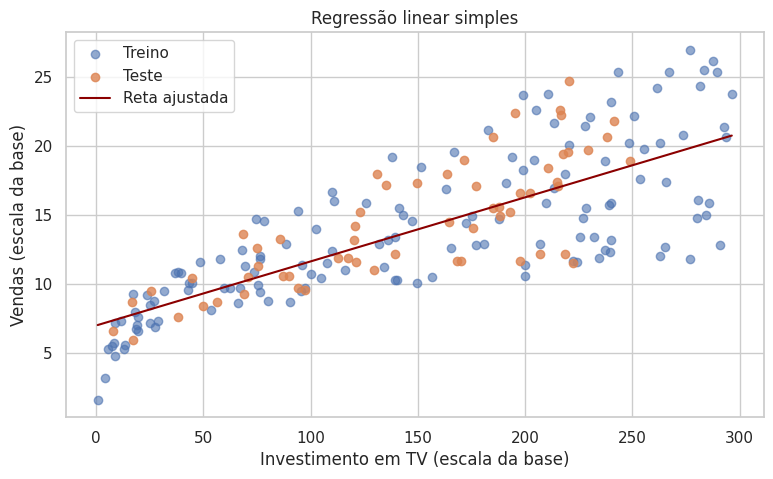

In [ ]:
grade_tv = pd.DataFrame({"TV": np.linspace(X_publicidade["TV"].min(), X_publicidade["TV"].max(), 100)})
plt.scatter(X_pub_treino["TV"], y_pub_treino, alpha=0.6, label="Treino")
plt.scatter(X_pub_teste["TV"], y_pub_teste, alpha=0.8, label="Teste")
plt.plot(grade_tv["TV"], modelo_publicidade.predict(grade_tv), color="darkred", label="Reta ajustada")
plt.xlabel("Investimento em TV (escala da base)")
plt.ylabel("Vendas (escala da base)")
plt.title("Regressão linear simples")
plt.legend()
plt.show()

## 8. Avaliando previsões
**MAE:** erro absoluto médio, na escala de Y. **RMSE:** raiz do erro quadrático médio, também na escala de Y; penaliza mais os erros grandes. **R²:** compara o erro do modelo ao de prever a média de Y no conjunto avaliado. Pode ser negativo no teste. Não é porcentagem de acertos.

In [ ]:
prev_pub = modelo_publicidade.predict(X_pub_teste)
resultado_pub = pd.DataFrame({"R²": [r2_score(y_pub_teste, prev_pub)],
    "MAE": [mean_absolute_error(y_pub_teste, prev_pub)],
    "RMSE": [np.sqrt(mean_squared_error(y_pub_teste, prev_pub))]})
display(resultado_pub.round(4))
display(pd.DataFrame({"TV": X_pub_teste["TV"], "Vendas observadas": y_pub_teste, "Vendas previstas": prev_pub, "Resíduo": y_pub_teste-prev_pub}).head(10).round(2))

,R²,MAE,RMSE
0,0.5943,2.162,2.8241


,TV,Vendas observadas,Vendas previstas,Resíduo
127,7.8,6.6,7.35,-0.75
105,238.2,20.7,18.07,2.63
100,135.2,17.2,13.28,3.92
93,217.7,19.4,17.11,2.29
112,241.7,21.8,18.23,3.57
168,206.8,12.2,16.61,-4.41
117,139.2,12.2,13.46,-1.26
97,197.6,11.7,16.18,-4.48
53,216.4,22.6,17.05,5.55
70,216.8,22.3,17.07,5.23


## 9. Resíduos
Resíduo positivo: o modelo subestimou a observação. Negativo: superestimou. Curvatura ou abertura em funil pode indicar inadequação da forma linear ou variância não constante. O gráfico não certifica sozinho os pressupostos.

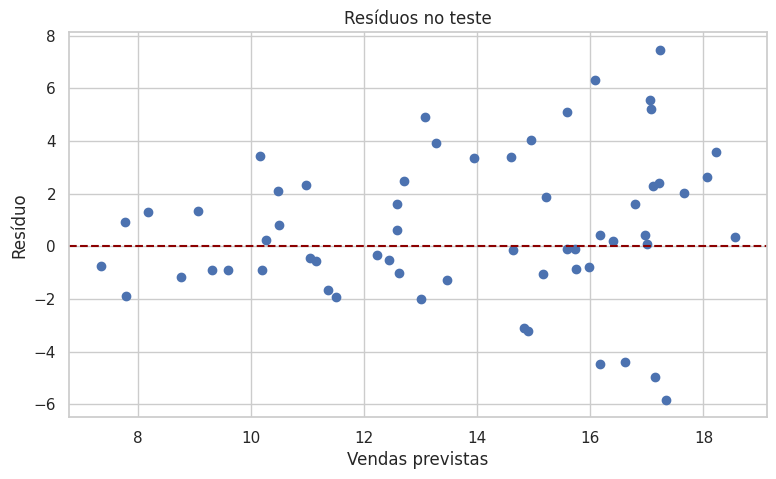

In [ ]:
residuos_pub = y_pub_teste - prev_pub
plt.scatter(prev_pub, residuos_pub)
plt.axhline(0, color="darkred", linestyle="--")
plt.xlabel("Vendas previstas")
plt.ylabel("Resíduo")
plt.title("Resíduos no teste")
plt.show()

## 10. Uma nova previsão
Altere o investimento abaixo. Confira se está dentro do intervalo observado. O resultado é uma estimativa pontual, com incerteza, e não uma garantia de vendas.

In [ ]:
investimento_tv = 100.0 # Altere este valor
entrada_pub = pd.DataFrame({"TV": [investimento_tv]})
print("Intervalo observado de TV:", publicidade["TV"].min(), "a", publicidade["TV"].max())
print(f"Vendas previstas: {modelo_publicidade.predict(entrada_pub)[0]:.2f}")

Intervalo observado de TV: 0.7 a 296.4
Vendas previstas: 11.64


## 11. Resultados estatísticos no treino
O statsmodels acrescenta a constante explicitamente. O resumo apresenta coeficientes, intervalos e testes. P-valores dependem dos pressupostos e não medem relevância gerencial nem comprovam causalidade. Normalidade de X ou Y não é requisito para ajustar mínimos quadrados; para inferência clássica em amostras pequenas, a hipótese normal se refere aos erros condicionais.

In [ ]:
ols_pub = sm.OLS(y_pub_treino, sm.add_constant(X_pub_treino)).fit()
print(ols_pub.summary())

                            OLS Regression Results                            
Dep. Variable:                 Vendas   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     219.0
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           2.84e-30
Time:                        17:17:29   Log-Likelihood:                -370.62
No. Observations:                 140   AIC:                             745.2
Df Residuals:                     138   BIC:                             751.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9897      0.548     12.762      0.0

## Discussão
1. Qual variável é X e qual é Y?
2. O que significa o coeficiente de TV?
3. Por que avaliar o modelo no teste?
4. O modelo permite afirmar que a publicidade causou as vendas? Justifique.
5. Compare previsões para TV = 50 e TV = 150, sem mudar o modelo.

# Parte 2. Área, localização e preço dos imóveis
O notebook original descreve 5.000 imóveis ofertados no Rio de Janeiro, com **Valor** (R$), **Area** (m²), **Dist_Praia** (km) e **Dist_Farmacia** (km). Essa descrição é do material enviado; não houve verificação independente da amostragem.

Primeiro ajustaremos Valor em função apenas de Area. Depois avançaremos para o modelo múltiplo com transformações usado no original.

A base de imóveis está incorporada na célula abaixo, em formato compactado. Ao executar, ela é descompactada e carregada em um DataFrame. São 5.000 observações e quatro variáveis. A cópia pública foi obtida no repositório RafaelxFernandes/Data-Science-e-Deep-Learning. Não foi possível verificar identidade integral com o arquivo original da Alura.

In [ ]:
import base64
import gzip

# Base de imóveis incorporada; execute sem alterar o conteúdo compactado.
base_imoveis_compactada = '...'
conteudo_imoveis = gzip.decompress(base64.b64decode(base_imoveis_compactada))
imoveis = pd.read_csv(io.BytesIO(conteudo_imoveis), sep=";")
imoveis.columns = imoveis.columns.str.strip()
colunas_imoveis = ["Valor", "Area", "Dist_Praia", "Dist_Farmacia"]
if not set(colunas_imoveis).issubset(imoveis.columns):
    raise ValueError("O CSV precisa conter Valor, Area, Dist_Praia e Dist_Farmacia.")
imoveis = imoveis[colunas_imoveis].apply(pd.to_numeric, errors="raise")
if not np.isfinite(imoveis.to_numpy()).all():
    raise ValueError("Existem valores ausentes ou infinitos. Revise a base antes do ajuste.")
if (imoveis[["Valor", "Area"]] <= 0).any().any() or (imoveis[["Dist_Praia", "Dist_Farmacia"]] < 0).any().any():
    raise ValueError("Valor e Area devem ser positivos; distâncias não podem ser negativas.")
print("Linhas e colunas:", imoveis.shape)
display(imoveis.head())

Linhas e colunas: (5000, 4)


,Valor,Area,Dist_Praia,Dist_Farmacia
0,4600000,280,0.240925,0.793637
1,900000,208,0.904136,0.134494
2,2550000,170,0.059525,0.423318
3,550000,100,2.883181,0.525064
4,2200000,164,0.239758,0.192374


## 12. Análise inicial
Observe a dispersão dos preços e a associação entre as variáveis. Pontos extremos não devem ser excluídos automaticamente.

,Valor,Area,Dist_Praia,Dist_Farmacia
count,5000.00,5000.00,5000.00,5000.00
mean,1402926.39,121.94,3.02,0.50
std,1883268.85,90.54,3.17,0.29
min,75000.00,16.00,0.00,0.00
25%,460000.00,70.00,0.44,0.24
50%,820000.00,93.00,1.48,0.50
75%,1590000.00,146.00,5.61,0.75
max,25000000.00,2000.00,17.96,1.00


,Valor,Area,Dist_Praia,Dist_Farmacia
Valor,1.000,0.711,-0.367,-0.024
Area,0.711,1.000,-0.283,-0.031
Dist_Praia,-0.367,-0.283,1.000,0.026
Dist_Farmacia,-0.024,-0.031,0.026,1.000


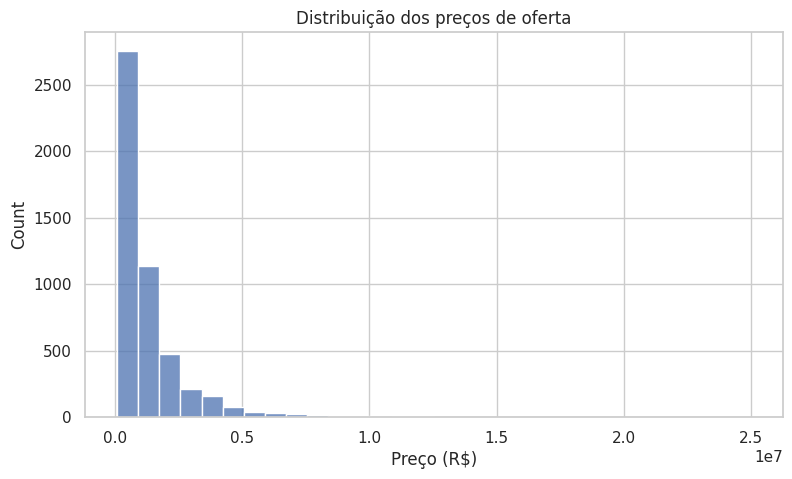

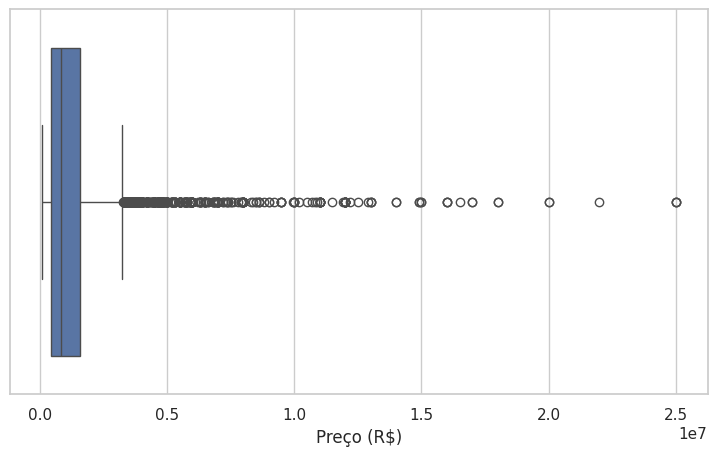

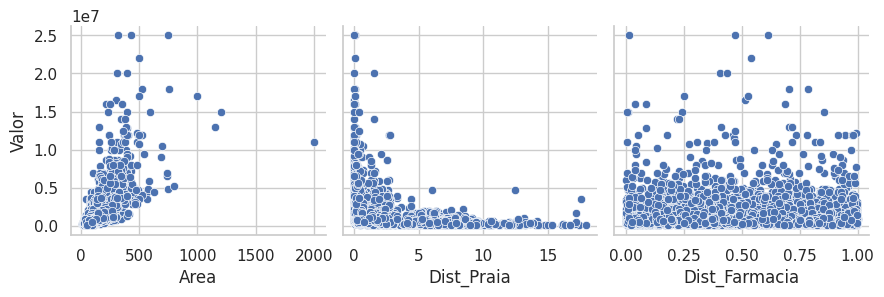

In [ ]:
display(imoveis.describe().round(2))
display(imoveis.corr().round(3))
sns.histplot(data=imoveis, x="Valor", bins=30)
plt.title("Distribuição dos preços de oferta")
plt.xlabel("Preço (R$)")
plt.show()
sns.boxplot(data=imoveis, x="Valor")
plt.xlabel("Preço (R$)")
plt.show()
sns.pairplot(imoveis, x_vars=["Area", "Dist_Praia", "Dist_Farmacia"], y_vars="Valor", height=3)
plt.show()

## 13. Regressão simples: área e preço
$$\widehat{Valor}=\widehat{\beta}_0+\widehat{\beta}_1Area$$
O coeficiente representa a variação no preço previsto, em reais, por m² adicional. A localização ainda não está controlada. Usaremos os mesmos imóveis no treino e no teste de todos os modelos desta parte.

Preço previsto = -424695.90 + 15091.63 × Área
Associação estimada por m² adicional: R$ 15091.63


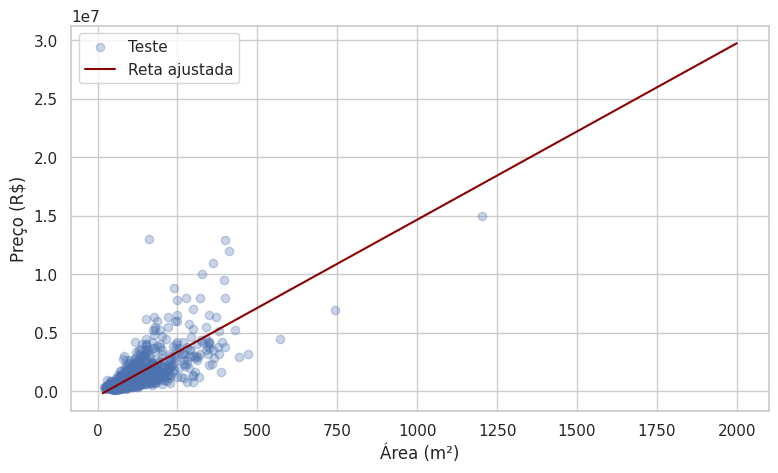

In [ ]:
indice_treino, indice_teste = train_test_split(imoveis.index, test_size=0.20, random_state=2811)
im_treino = imoveis.loc[indice_treino]
im_teste = imoveis.loc[indice_teste]
modelo_area = LinearRegression().fit(im_treino[["Area"]], im_treino["Valor"])
prev_area = modelo_area.predict(im_teste[["Area"]])
print(f"Preço previsto = {modelo_area.intercept_:.2f} + {modelo_area.coef_[0]:.2f} × Área")
print(f"Associação estimada por m² adicional: R$ {modelo_area.coef_[0]:.2f}")
grade_area = pd.DataFrame({"Area": np.linspace(imoveis.Area.min(), imoveis.Area.max(), 100)})
plt.scatter(im_teste.Area, im_teste.Valor, alpha=0.3, label="Teste")
plt.plot(grade_area.Area, modelo_area.predict(grade_area), color="darkred", label="Reta ajustada")
plt.xlabel("Área (m²)")
plt.ylabel("Preço (R$)")
plt.legend()
plt.show()

## 14. Por que transformar?
O logaritmo pode ajudar a representar associações multiplicativas e reduzir assimetria. Não é obrigatório porque Y não seja normal. A adequação deve ser examinada pelos resíduos e pela avaliação fora do treino.

Como no original, usamos log natural do preço, da área e de (1 + distância). Adicionar 1 permite incluir distância zero. A unidade adotada para a distância influencia essa transformação.

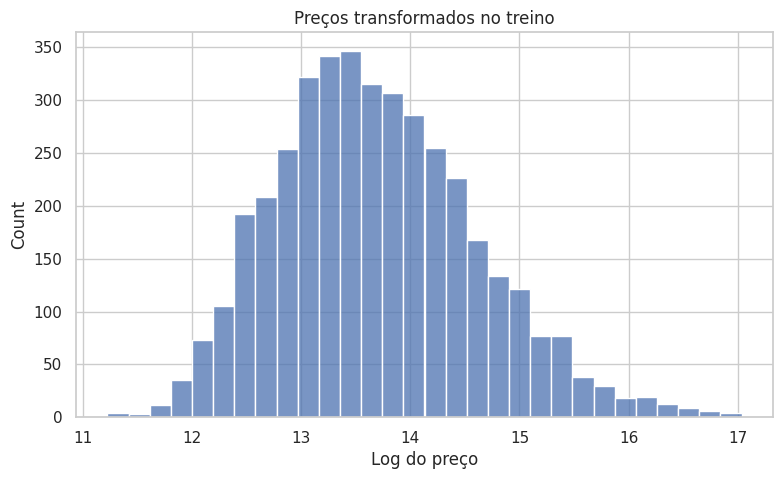

In [ ]:
log_treino = pd.DataFrame({"log_Area": np.log(im_treino.Area),
    "log_Dist_Praia": np.log1p(im_treino.Dist_Praia),
    "log_Dist_Farmacia": np.log1p(im_treino.Dist_Farmacia)}, index=im_treino.index)
log_teste = pd.DataFrame({"log_Area": np.log(im_teste.Area),
    "log_Dist_Praia": np.log1p(im_teste.Dist_Praia),
    "log_Dist_Farmacia": np.log1p(im_teste.Dist_Farmacia)}, index=im_teste.index)
y_log_treino = np.log(im_treino.Valor)
y_log_teste = np.log(im_teste.Valor)
sns.histplot(y_log_treino, bins=30)
plt.xlabel("Log do preço")
plt.title("Preços transformados no treino")
plt.show()

## 15. Modelo múltiplo completo
$$\widehat{\ln(Valor)}=\widehat{\beta}_0+\widehat{\beta}_1\ln(Area)+\widehat{\beta}_2\ln(1+Dist\_Praia)+\widehat{\beta}_3\ln(1+Dist\_Farmacia)$$
Agora há três variáveis explicativas. Os coeficientes são associações condicionais às outras variáveis incluídas.

In [ ]:
ols_im_completo = sm.OLS(y_log_treino, sm.add_constant(log_treino)).fit()
print(ols_im_completo.summary())
modelo_im_completo = LinearRegression().fit(log_treino, y_log_treino)

                            OLS Regression Results                            
Dep. Variable:                  Valor   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     5495.
Date:                Tue, 06 Oct 2026   Prob (F-statistic):               0.00
Time:                        17:17:32   Log-Likelihood:                -2044.9
No. Observations:                4000   AIC:                             4098.
Df Residuals:                    3996   BIC:                             4123.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 9.3417      0.06

## 16. Modelo reduzido do notebook original
O original retira a distância à farmácia. Vamos apresentar essa especificação para comparação, sem afirmar antecipadamente que é melhor. Não escolha repetidamente variáveis pelo resultado do teste; para seleção, use validação no treino e reserve um teste final.

In [ ]:
variaveis_reduzidas = ["log_Area", "log_Dist_Praia"]
ols_im_reduzido = sm.OLS(y_log_treino, sm.add_constant(log_treino[variaveis_reduzidas])).fit()
print(ols_im_reduzido.summary())
modelo_im_reduzido = LinearRegression().fit(log_treino[variaveis_reduzidas], y_log_treino)
display(pd.DataFrame({"Variável": ["Intercepto"] + variaveis_reduzidas,
    "Coeficiente": np.r_[modelo_im_reduzido.intercept_, modelo_im_reduzido.coef_]}).round(4))

                            OLS Regression Results                            
Dep. Variable:                  Valor   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     8244.
Date:                Tue, 06 Oct 2026   Prob (F-statistic):               0.00
Time:                        17:17:32   Log-Likelihood:                -2045.1
No. Observations:                4000   AIC:                             4096.
Df Residuals:                    3997   BIC:                             4115.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              9.3349      0.059    158.

,Variável,Coeficiente
0,Intercepto,9.3349
1,log_Area,1.0581
2,log_Dist_Praia,-0.4906


## 17. Interpretando corretamente
**Área:** no modelo reduzido, aumento de 1% na área associa-se aproximadamente a β₁% no preço, mantendo a distância constante.

**Distância:** β₂ é a elasticidade em relação a **1 + distância**, não à distância diretamente. Para a distância d, a elasticidade local é β₂d/(1+d).

**Intercepto:** log_Area = 0 significa área de 1 m²; log(1 + distância) = 0 significa distância zero. Não corresponde à exclusão das variáveis. Pode não ter interpretação prática no intervalo observado.

In [ ]:
beta_area, beta_praia = modelo_im_reduzido.coef_
print(f"Efeito percentual exato de +1% na área: {100*((1.01)**beta_area-1):.4f}%")
distancia_inicial = 1.0
distancia_final = 2.0
variacao_distancia = 100 * (((1+distancia_final)/(1+distancia_inicial))**beta_praia-1)
print(f"Variação prevista de {distancia_inicial} para {distancia_final} km: {variacao_distancia:.2f}%, mantendo a área.")

Efeito percentual exato de +1% na área: 1.0584%
Variação prevista de 1.0 para 2.0 km: -18.04%, mantendo a área.


## 18. Voltando à escala de reais
Aplicar exp à previsão em log não fornece, em geral, a média condicional em reais. Sob erro normal e centrado em log, corresponde à mediana condicional.

Para estimar a média, mostramos a correção de retransformação pelo fator de Duan: média de exp(resíduo) no treino. Um fator global pressupõe que essa correção seja adequada ao longo de X; heterocedasticidade pode exigir correção condicional. Nunca estime o fator com resíduos do teste.

In [ ]:
prev_log_completo = modelo_im_completo.predict(log_teste)
prev_log_reduzido = modelo_im_reduzido.predict(log_teste[variaveis_reduzidas])
fator_completo = np.mean(np.exp(y_log_treino-modelo_im_completo.predict(log_treino)))
fator_reduzido = np.mean(np.exp(y_log_treino-modelo_im_reduzido.predict(log_treino[variaveis_reduzidas])))
prev_reais_completo = np.exp(prev_log_completo)*fator_completo
prev_reais_reduzido = np.exp(prev_log_reduzido)*fator_reduzido
print("Fator de correção do modelo reduzido:", round(fator_reduzido, 4))

Fator de correção do modelo reduzido: 1.0874


## 19. Comparando modelos na mesma escala
Compare MAE e RMSE em reais, nos mesmos imóveis do teste. R² em log e R² em reais têm denominadores diferentes e não devem ser comparados diretamente como se fossem a mesma resposta.

In [ ]:
def avaliar_reais(nome, observado, previsto):
    return {"Modelo": nome, "R² em reais": r2_score(observado, previsto),
            "MAE (R$)": mean_absolute_error(observado, previsto),
            "RMSE (R$)": np.sqrt(mean_squared_error(observado, previsto))}
comparacao_imoveis = pd.DataFrame([
    avaliar_reais("Simples: área", im_teste.Valor, prev_area),
    avaliar_reais("Múltiplo completo: log + correção", im_teste.Valor, prev_reais_completo),
    avaliar_reais("Múltiplo reduzido: log + correção", im_teste.Valor, prev_reais_reduzido)])
display(comparacao_imoveis.round(3))
print("R² do reduzido na escala log:", round(r2_score(y_log_teste, prev_log_reduzido), 4))

,Modelo,R² em reais,MAE (R$),RMSE (R$)
0,Simples: área,0.536,617271.836,1053564.631
1,Múltiplo completo: log + correção,0.613,492141.689,963171.021
2,Múltiplo reduzido: log + correção,0.614,491669.477,961208.442


R² do reduzido na escala log: 0.7904


## 20. Diagnóstico do modelo reduzido
Os resíduos do treino ajudam a examinar a especificação. A comparação observado × previsto no teste mostra o desempenho fora do ajuste. Pontos próximos à diagonal indicam previsões próximas aos valores observados.

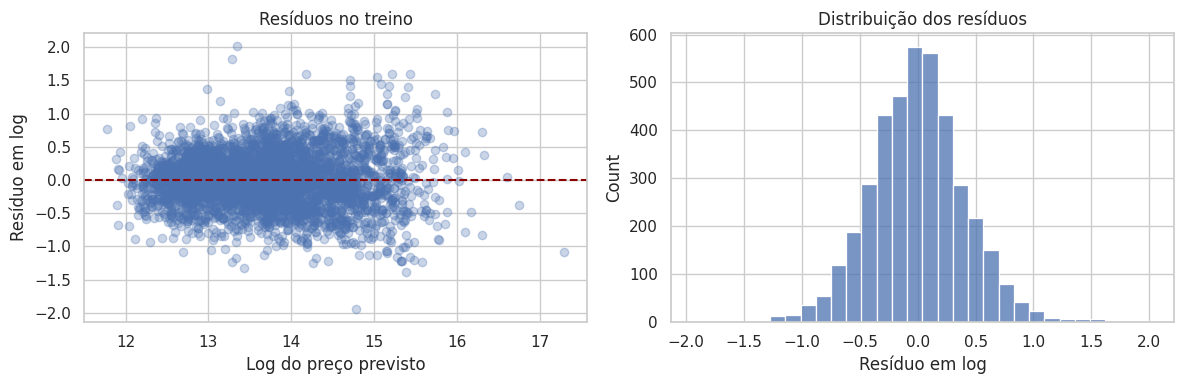

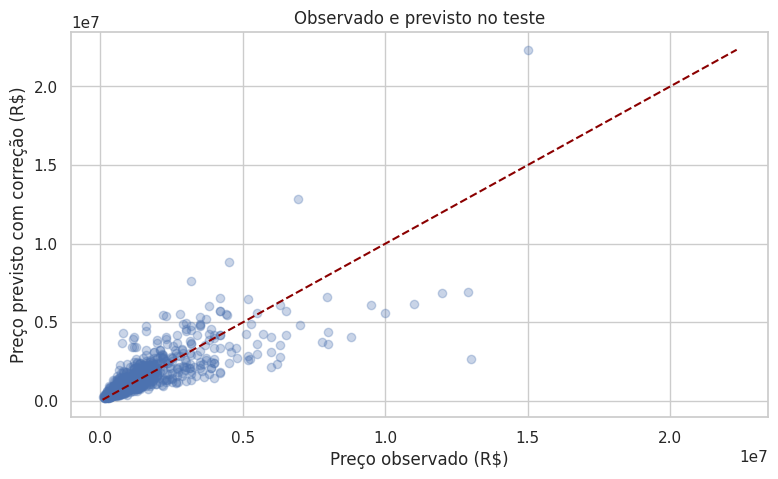

In [ ]:
ajuste_log_treino = modelo_im_reduzido.predict(log_treino[variaveis_reduzidas])
residuos_log = y_log_treino-ajuste_log_treino
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(ajuste_log_treino, residuos_log, alpha=0.3)
ax[0].axhline(0, color="darkred", linestyle="--")
ax[0].set(xlabel="Log do preço previsto", ylabel="Resíduo em log", title="Resíduos no treino")
sns.histplot(residuos_log, bins=30, ax=ax[1])
ax[1].set(xlabel="Resíduo em log", title="Distribuição dos resíduos")
plt.tight_layout()
plt.show()
plt.scatter(im_teste.Valor, prev_reais_reduzido, alpha=0.3)
limites = [min(im_teste.Valor.min(), prev_reais_reduzido.min()), max(im_teste.Valor.max(), prev_reais_reduzido.max())]
plt.plot(limites, limites, color="darkred", linestyle="--")
plt.xlabel("Preço observado (R$)")
plt.ylabel("Preço previsto com correção (R$)")
plt.title("Observado e previsto no teste")
plt.show()

## 21. Estimativa de um imóvel
Altere a área e a distância. Confira os intervalos observados, lembrando que estar dentro dos intervalos individuais não garante que a combinação esteja bem representada. Não há intervalo de previsão nesta estimativa pontual.

In [ ]:
area_nova = 150.0
distancia_praia_nova = 1.0
if area_nova <= 0 or distancia_praia_nova < 0:
    raise ValueError("Área deve ser positiva e distância não negativa.")
entrada_imovel = pd.DataFrame({"log_Area": [np.log(area_nova)], "log_Dist_Praia": [np.log1p(distancia_praia_nova)]})
estimativa_log = modelo_im_reduzido.predict(entrada_imovel)[0]
print(f"Exp da previsão em log: R$ {np.exp(estimativa_log):,.2f}")
print(f"Previsão com correção global: R$ {np.exp(estimativa_log)*fator_reduzido:,.2f}")
display(imoveis[["Area", "Dist_Praia"]].agg(["min", "max"]))

Exp da previsão em log: R$ 1,617,664.12
Previsão com correção global: R$ 1,759,078.64


,Area,Dist_Praia
min,16,0.000000
max,2000,17.962942


## Discussão final
1. Qual a diferença entre regressão simples e múltipla?
2. Qual modelo teve menor erro em reais no teste?
3. Como interpretar o coeficiente da área no modelo transformado?
4. Por que a distância à praia exige cuidado na interpretação?
5. Que características ausentes poderiam explicar o preço de um imóvel?

| Aspecto | Publicidade | Imóveis |
|---|---|---|
| Resposta | Vendas | Preço de oferta |
| Modelo inicial | Simples: TV | Simples: área |
| Extensão | Outros canais podem ser incluídos | Múltiplo com área e localização |
| Escala principal | Escala original da base | Reais e logaritmos |
| Avaliação | Teste separado | Mesmos imóveis do teste para comparação |

## Fontes e materiais
- Notebook de referência: [Ashish Yadav, Sales Prediction (Simple Linear Regression), Kaggle](https://www.kaggle.com/code/ashydv/sales-prediction-simple-linear-regression/notebook). A interface consultada não expôs o código integral; a parte de publicidade é uma implementação própria da mesma proposta.
- CSV Advertising incorporado: [selva86/datasets, Advertising.csv](https://github.com/selva86/datasets/blob/master/Advertising.csv).
- Parte de imóveis: notebook `Regressão Linear.ipynb`, fornecido pela docente. O CSV de imóveis foi incorporado a partir da cópia pública identificada abaixo. As imagens locais foram substituídas por gráficos gerados em Python.
- [Documentação LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).
- [Documentação OLS](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html).

As métricas e os coeficientes são calculados durante a execução; nenhum resultado numérico do notebook original foi fixado como resultado deste material.
- CSV de imóveis: [RafaelxFernandes/Data-Science-e-Deep-Learning](https://github.com/RafaelxFernandes/Data-Science-e-Deep-Learning/tree/main), pasta “8 - Regressão Linear_ Técnicas Avançadas de Modelagem/Dados”.
